### Plot short snippets of data with spikes overlaying on top

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from ripple_detection.core import segment_boolean_series

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2025-10-16 14:21:33,599][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [72]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMind,LFPBandArtifact,TrialChoice,EpochPos,MUA,get_linearization_map
from spyglass.shijiegu.decodeHelpers import runSessionNames, session2position_name
from spyglass.shijiegu.changeOfMind import (find_turnaround_time, findProportion,
            find_trials, load_epoch_data_wrapper, find_direction, find_trials_animal, findDirectionPlot)
from spyglass.shijiegu.load import load_run_sessions, load_decode
from spyglass.shijiegu.singleUnit_sortedDecode import place_field_direction, color_cells_by_place_direction
from spyglass.shijiegu.singleUnit import electrode_unit

In [9]:
from spyglass.spikesorting.v0 import Curation

In [4]:
from spyglass.shijiegu.changeOfMind_figures.example_snippet import plot_decode_spiking, save_data

In [23]:
examples_short = [('lewis20240109_.nwb', 2, "06_Rev2Session3", 14, 2, (-1.5,2.5)),
            ('lewis20240109_.nwb', 2, "06_Rev2Session3", 28, 0, (-1.5,3)), # remote
            ('molly20220418_.nwb', 4, "10_Seq2Session5", 34, 0, (-0.5,1)), #day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
            ('eliot20221021_.nwb', 1, "04_Seq2Session2", 29, 0, (-1,3.5))
           ] 
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4'

In [26]:
# use 2D decode, causal, 2ms bin
param_name1 = "2Dcausal2ms"
param1 = {"variant":param_name1, "likelihood": False, "causal": True, "use_1d_decode": False, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, causal, 2ms bin
param_name2 = "1Dcausal2ms"
param2 = {"variant":param_name2, "likelihood": False, "causal": True, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, acausal, 2ms bin
param_name3 = "1Dacausal2ms"
param3 = {"variant":param_name3, "likelihood": False, "causal": False, "use_1d_decode": True, "classifier_param_name": 'default_decoding_gpu_4armMaze'}

# use 1D decode, likelihood, 40ms bin
param_name4 = "1Dlikelihood40ms"
param4 = {"variant":param_name4, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W40msO20ms"}

# use 1D decode, likelihood, 20ms bin
param_name5 = "1Dlikelihood20ms"
param5 = {"variant":param_name5, "likelihood": True, "causal": None, "use_1d_decode": True, "classifier_param_name": "default_decoding_gpu_4armMaze_W20msO10ms"}

params = [param1,param2,param3,param4,param5]

## save spike data

In [116]:
curation_id = 0

In [121]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4'

for example in examples_short:
    
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty) = example
    animal = nwb_copy_file_name[:5]
    # load spikes
    position_name = session2position_name(nwb_copy_file_name, session_name)
    
    (cells, smoothed_placefield, placefield_peak,
                spike_count_by_arm_direction, time_spent_by_arm_direction, betaPdfs, means) = place_field_direction(nwb_copy_file_name,
                                                                                       session_name,position_name,
                                                                                       curation_id = curation_id)
        
    print(f"This session has {len(cells)} neurons.")
        
    # make colorlist for cells 
    cell_color = color_cells_by_place_direction(cells, placefield_peak, spike_count_by_arm_direction)

    # save data for spikes
    plot_data_filename = f"spikeinfo_curation{curation_id}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"
    output_path = os.path.join(output_folder,plot_data_filename) #os.join(output_folder,plot_data_filename)
    data = {"cells":cells,"cell_color":cell_color,
            "smoothed_placefield":smoothed_placefield,"placefield_peak":placefield_peak,
            "spike_count_by_arm_direction":spike_count_by_arm_direction,"time_spent_by_arm_direction":time_spent_by_arm_direction,
            "betaPdfs":betaPdfs,"means":means
           }
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)


[2025-10-16 21:44:03,230][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:44:03,250][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:44:03,256][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:44:03,290][WARNING]: Skipped checksum for file with hash: 578385f5-61b2-0222-8267-000f7c564355, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_6E2AM9IFHQ.nwb
[2025-10-16 21:44:03,310][WARNING]: Skipped checksum for file with hash: 578385f5-61b2-0222-8267-000f7c564355, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_6E2AM9IFHQ.nwb
[2025-10-16 21:44:03,316][WARNING]: Skipped checksum for file with hash: 57

spike num: 4542


[21:44:06][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:44:06][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-16 21:44:06,728][WARNING]: Skipped checksum for file with hash: 49b590e0-1ad7-d4bb-f49e-0dcb9251da79, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H29KE3CK69.nwb
[2025-10-16 21:44:06,739][WARNING]: Skipped checksum for file with hash: 49b590e0-1ad7-d4bb-f49e-0dcb9251da79, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H29KE3CK69.nwb
[2025-

spike num: 3780


	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:44:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-16 21:44:07,122][WARNING]: Skipped checksum for file with hash: 49b590e0-1ad7-d4bb-f49e-0dcb9251da79, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H29KE3CK69.nwb
[2025-10-16 21:44:07,147][WARNING]: Skipped checksum for file with hash: 49b590e0-1ad7-d4bb-f49e-0dcb9251da79, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H29KE3CK69.nwb
[2025-10-16 21:44:07,155][WARNING]: Skipped checksum for file with hash: 49b590e0-1ad7-d4bb-f49e-0dcb9251da79, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H29KE3CK69.nwb
[2025-10-16 21:

...

spike num: 5186


[21:50:14][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-16 21:50:14,762][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:14,783][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:14,789][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:14,818][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb

spike num: 2832


[21:50:15][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-16 21:50:15,191][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:15,216][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:15,224][WARNING]: Skipped checksum for file with hash: 806c7f37-82e3-2839-6b6e-80d6a4e17778, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_FWU7MSI3UP.nwb
[2025-10-16 21:50:15,258][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb

This session has 72 neurons.


## plot

In [122]:
curation = 0

[21:58:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dlikelihood20ms_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


[21:58:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[2025-10-16 21:58:32,057][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:58:32,067][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:58:32,071][WARNING]: Skipped checksum for file with hash: c92aab32-62ad-f01b-6712-9149d7fc475d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_FL8YWUBHDA.nwb
[2025-10-16 21:58:32,105][WARNING]: Skipped checksum for file with hash: 578385f5-61b2-0222-8267-000f7c564355, and path: /stelmo/nwb/analysis/lewis20240109/lewis2024

Spike data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/spikeinfo_curation0_lewis_lewis20240109_.nwb_06_Rev2Session3_trial14.pkl


[2025-10-16 21:58:32,189][WARNING]: Skipped checksum for file with hash: caf8268f-17e7-9093-e883-0a96fe4085fc, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_1NR4YN931X.nwb
[2025-10-16 21:58:32,205][WARNING]: Skipped checksum for file with hash: caf8268f-17e7-9093-e883-0a96fe4085fc, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_1NR4YN931X.nwb
[2025-10-16 21:58:32,209][WARNING]: Skipped checksum for file with hash: caf8268f-17e7-9093-e883-0a96fe4085fc, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_1NR4YN931X.nwb
[2025-10-16 21:58:32,254][WARNING]: Skipped checksum for file with hash: 59b53f1a-adbc-6cb1-0862-92f606f576b1, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_G5KTYCL5Z6.nwb
[2025-10-16 21:58:32,273][WARNING]: Skipped checksum for file with hash: 59b53f1a-adbc-6cb1-0862-92f606f576b1, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_G5KTYCL5Z6.nwb
[2025-10-16 21:58:32,278][WARNING]: Skipped checksum for file with hash: 59

...

[2025-10-16 21:58:42,266][WARNING]: Skipped checksum for file with hash: e886de16-d87b-549e-2f9c-4ddcf9de330d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_FCK0ZNHHWI.nwb
[2025-10-16 21:58:42,296][WARNING]: Skipped checksum for file with hash: ff6802f4-3ac4-d41b-21a1-e41c5481bfc4, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_6AACYDYHPT.nwb
[2025-10-16 21:58:42,309][WARNING]: Skipped checksum for file with hash: ff6802f4-3ac4-d41b-21a1-e41c5481bfc4, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_6AACYDYHPT.nwb
[2025-10-16 21:58:42,314][WARNING]: Skipped checksum for file with hash: ff6802f4-3ac4-d41b-21a1-e41c5481bfc4, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_6AACYDYHPT.nwb
[2025-10-16 21:58:42,344][WARNING]: Skipped checksum for file with hash: fec32b37-8734-5d93-b746-3c542d30e0ad, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_A8YSJHSUJ9.nwb
[2025-10-16 21:58:42,356][WARNING]: Skipped checksum for file with hash: fe

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/data_variant1Dlikelihood20ms_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


[21:58:45][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[2025-10-16 21:58:45,164][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 21:58:45,182][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 21:58:45,188][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 21:58:45,231][WARNING]: Skipped checksum for file with hash: 9738e542-3175-0c49-63eb-e935d158ee87, and path: /stelmo/nwb/analysis/eliot20221021/eliot2022

Spike data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/spikeinfo_curation0_eliot_eliot20221021_.nwb_04_Seq2Session2_trial29.pkl


[2025-10-16 21:58:45,321][WARNING]: Skipped checksum for file with hash: b68a7bff-598f-cc50-c552-c002bbbe6277, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_30F4JQYV90.nwb
[2025-10-16 21:58:45,327][WARNING]: Skipped checksum for file with hash: b68a7bff-598f-cc50-c552-c002bbbe6277, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_30F4JQYV90.nwb
[2025-10-16 21:58:45,375][WARNING]: Skipped checksum for file with hash: 37417018-edfc-4b57-6503-c9aaea23e4d0, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_H6X6UC1ZC1.nwb
[2025-10-16 21:58:45,395][WARNING]: Skipped checksum for file with hash: 37417018-edfc-4b57-6503-c9aaea23e4d0, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_H6X6UC1ZC1.nwb
[2025-10-16 21:58:45,401][WARNING]: Skipped checksum for file with hash: 37417018-edfc-4b57-6503-c9aaea23e4d0, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_H6X6UC1ZC1.nwb
[2025-10-16 21:58:45,447][WARNING]: Skipped checksum for file with hash: 71

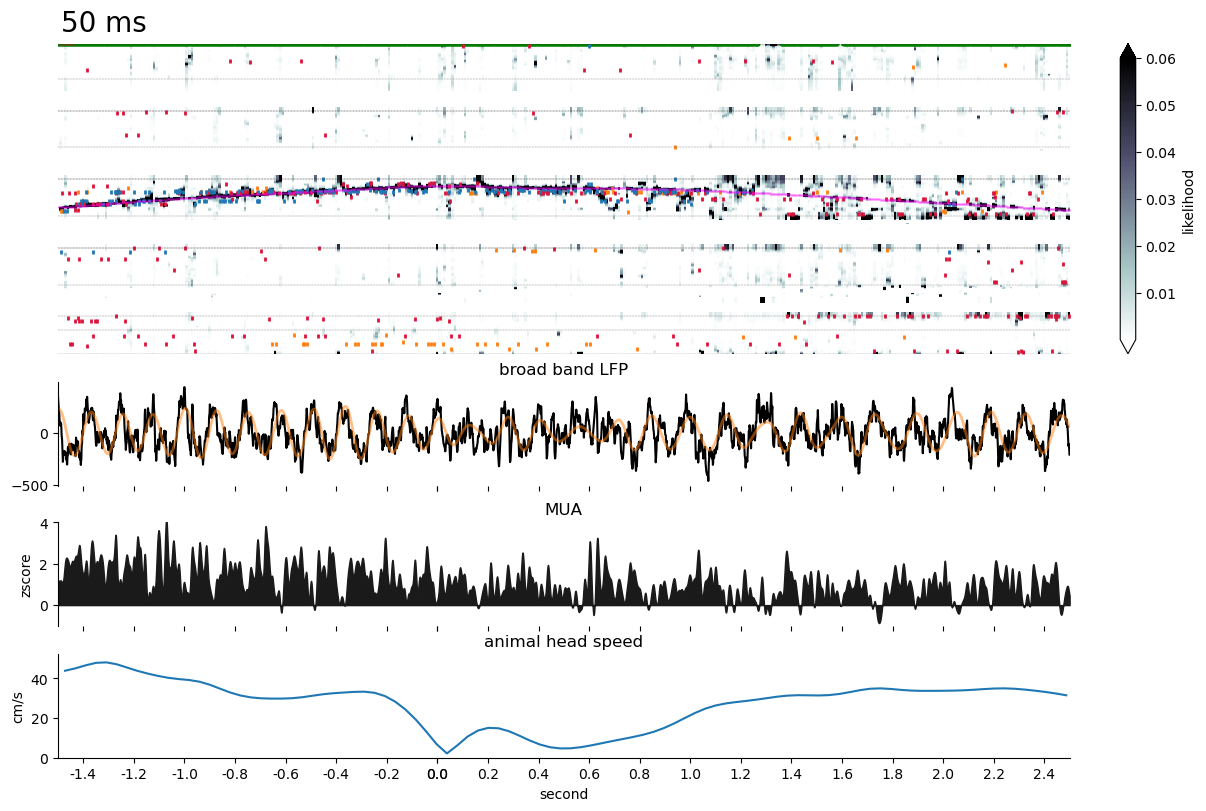

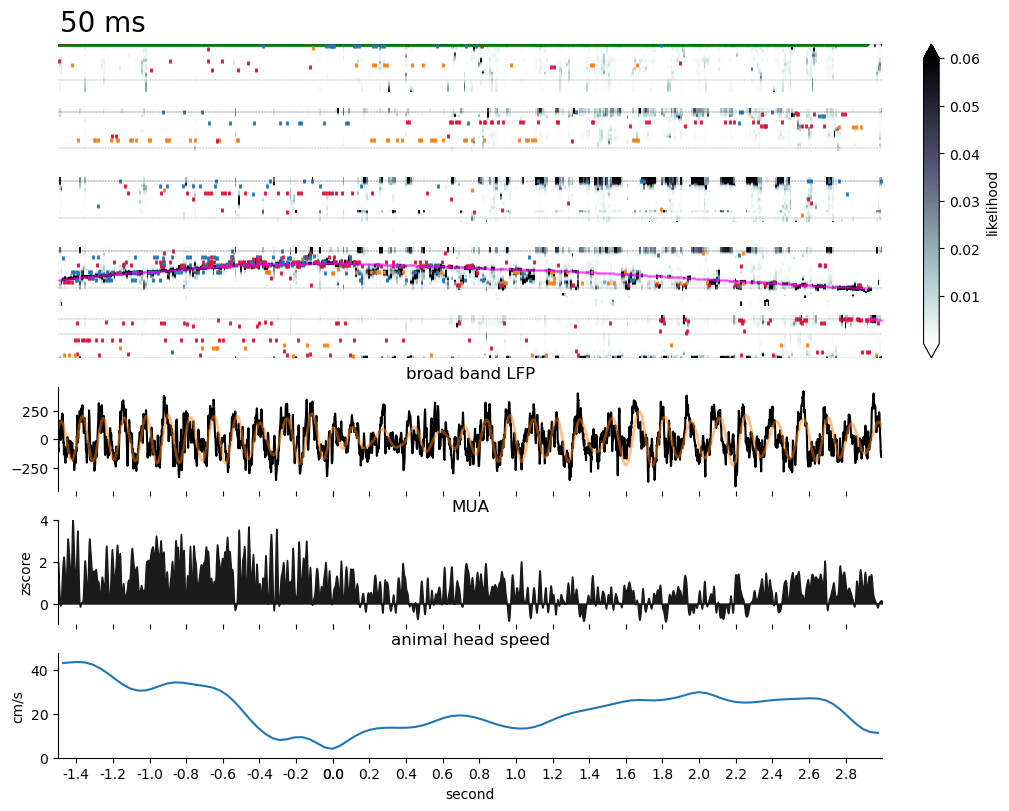

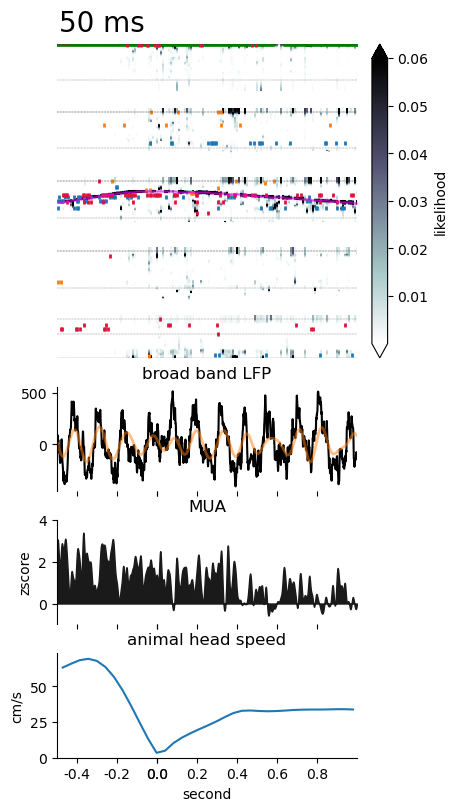

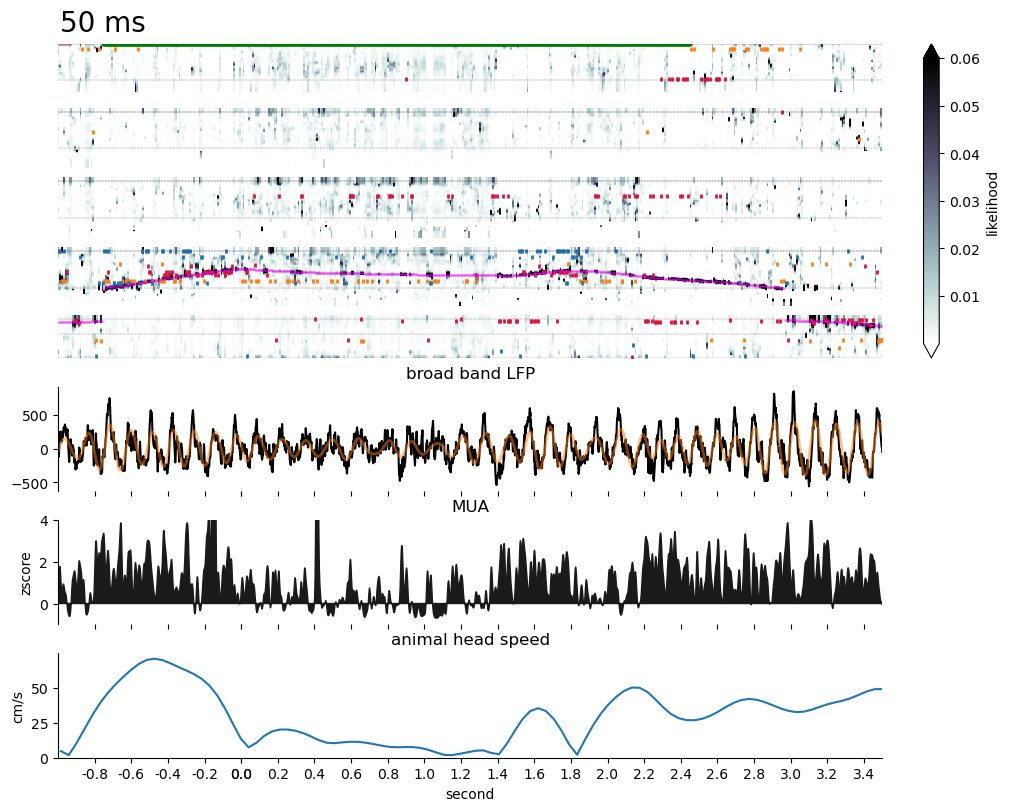

In [123]:
for example in examples_short:
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty) = example
    animal = nwb_copy_file_name[:5]
    
    param = param5
    variant = param["variant"]

    # load basic plot data
    plot_data_filename = f"data_variant{variant}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"
    
    output_path = os.path.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")
            
    fig, axes = plot_decode_spiking(data["plottimes"],data["linear_position_subset"],data["decode"],data["theta_subset"],
                            data["lfp_subset"], data["mua_subset"], data["head_speed_subset"],
                            savefolder=[], savename= "spike_" + plot_data_filename,
                            t0 = data["t0"], plot_len = None,
                            turnaround = None, likelihood = True,
                            head_direction_sign = data["head_direction_sign"], vmax = 0.06)

    # load spike data
    plot_data_filename = f"spikeinfo_curation{curation_id}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"
    output_path = os.path.join(output_folder,plot_data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data_spike = pickle.load(file)
    print(f"Spike data loaded from {output_path}")

    placefield_peak = data_spike["placefield_peak"]
    #cell_color = data_spike["cell_color"]
    plottimes = data["plottimes"]
    e_old = None
    cell_color = color_cells_by_place_direction(data_spike["cells"], data_spike["placefield_peak"], data_spike["spike_count_by_arm_direction"])
    
    for cell in data_spike["cells"]:
        e,u = cell
        if e != e_old:
            e_old = e
            nwb_units = electrode_unit(nwb_copy_file_name,session_name,e,curation_id = 0)
    
        spike_times = nwb_units.loc[u].spike_times
        spike_times = spike_times[np.logical_and(spike_times >= plottimes[0],spike_times <= plottimes[1])]

        # add spikes
        axes[0].scatter(spike_times, np.zeros(len(spike_times)) + placefield_peak[(e,u)],
                        rasterized=True, marker='|', color = cell_color[(e,u)],s = 10,linewidth=2)

    fig = axes[0].get_figure()

    savefolder=data["output_folder"]
    savename= "spike_" + plot_data_filename
    fig.savefig(os.path.join(savefolder,savename+'.pdf'),format="pdf",bbox_inches='tight',dpi=200)

[2025-10-16 20:50:43,870][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 20:50:43,890][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 20:50:43,896][WARNING]: Skipped checksum for file with hash: 1ea8d723-320e-09cf-6523-d08853063b29, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_1PUGVCD2HU.nwb
[2025-10-16 20:50:43,949][WARNING]: Skipped checksum for file with hash: 9738e542-3175-0c49-63eb-e935d158ee87, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_3HXWVWQ8BT.nwb
[2025-10-16 20:50:43,969][WARNING]: Skipped checksum for file with hash: 9738e542-3175-0c49-63eb-e935d158ee87, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_3HXWVWQ8BT.nwb
[2025-10-16 20:50:43,980][WARNING]: Skipped checksum for file with hash: 97